In [3]:
import pandas as pd
import numpy as np
import os
import sys
%load_ext autoreload
%autoreload 2
# sys.path.append('/home/wolfgang/repos/sleep_research_io')
# from sleep_research_functions import *
# %matplotlib widget
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from icu_sleep_breathing_2020_help_functions import * 

pd.options.display.max_rows = 300
pd.options.display.max_columns = 300

font = {'family' : 'normal',
        'weight' : 'normal',
        'size'   : 8}

matplotlib.rc('font', **font)

### load summary tables:

In [4]:
plots_savedir = '/media/mad3/Projects/ICU_SLEEP_STUDY/Sleep_And_Breathing/plots'
if not os.path.exists(plots_savedir):
    plots_savedir = 'C:/Users/Wolfgang/Dropbox (Partners HealthCare)/SleepInICUandSleeplabPaper/Plots'

In [5]:
[summary_subjects_icu, summary_subjects_sleeplab, 
 summary_days_icu, summary_days_sleeplab] = load_summary_data_with_inclusion_criteria(sleeplab_matched=True)

# of subjects ICU before inclusion criteria: 108
# of 12-hour segments ICU before inclusion criteria: 1230
# of subjects ICU after inclusion criteria: 103
# of 12-hour segments ICU after inclusion criteria: 621
24-hour segments: 256
12-hour segments: 365

# of subjects sleeplab before inclusion criteria: 307
# of 12-hour segments sleeplab before inclusion criteria: 307
# of subjects sleeplab after inclusion criteria: 307
# of 12-hour segments sleeplab after before inclusion criteria: 307


In [6]:
for modality in ['breathing', 'ecg_nn']:
    var_n2 = 'stages_distribution_MODALITY_N2'.replace('MODALITY', modality)
    var_n3 = 'stages_distribution_MODALITY_N3'.replace('MODALITY', modality)
    var_sum = 'stages_distribution_MODALITY_N2N3'.replace('MODALITY', modality)
    
    summary_days_icu[var_sum] = summary_days_icu[var_n2] + summary_days_icu[var_n3]
    summary_days_sleeplab[var_sum] = summary_days_sleeplab[var_n2] + summary_days_sleeplab[var_n3]

In [7]:
summary_days_icu.loc[:, ['stages_distribution' in x for x in summary_days_icu.columns]] *= 100
summary_days_sleeplab.loc[:, ['stages_distribution' in x for x in summary_days_sleeplab.columns]] *= 100

summary_f_icu = summary_days_icu.loc[summary_days_icu.day_cat == 'f', :]
summary_dn_icu = summary_days_icu.loc[summary_days_icu.day_cat != 'f', :]

summary_days_sleeplab_full = summary_days_sleeplab.copy()

In [8]:
summary_days_sleeplab = summary_days_sleeplab_full.loc[summary_days_sleeplab_full.matched_all == 1].copy()

min_hours_sleep_icu = 4
icu_4 = summary_dn_icu.loc[np.any([summary_dn_icu.sleep_hours_breathing >= min_hours_sleep_icu, 
                                               summary_dn_icu.sleep_hours_ecg_nn >= min_hours_sleep_icu],
                                               axis=0), :]

icu_4_strict = summary_dn_icu.loc[np.all([summary_dn_icu.sleep_hours_breathing >= min_hours_sleep_icu, 
                                               summary_dn_icu.sleep_hours_ecg_nn >= min_hours_sleep_icu],
                                               axis=0), :]

print(f'Number of ICU 12-hour segments {summary_dn_icu.shape[0]}')
print(f'Number of ICU 12-hour segments with #hours of sleep > {min_hours_sleep_icu} (any of ECG or Resp. Model): {icu_4.shape[0]}')
print(f'Number of ICU 12-hour segments with #hours of sleep > {min_hours_sleep_icu} (both ECG and Resp. Model): {icu_4_strict.shape[0]}')

Number of ICU 12-hour segments 365
Number of ICU 12-hour segments with #hours of sleep > 4 (any of ECG or Resp. Model): 262
Number of ICU 12-hour segments with #hours of sleep > 4 (both ECG and Resp. Model): 101


In [9]:
ahi_categories = ['all', 'ahi_0_5', 'ahi_5_15', 'ahi_15_30', 'ahi_30_100', 'ahi_15_100']
ahi_names = {
    'all': 'All',
    'ahi_0_5': 'AHI < 5',
    'ahi_5_15': '5 < AHI <=15',
    'ahi_15_30': '15 < AHI <= 30',
    'ahi_30_100': 'AHI > 30',
    'ahi_15_100': 'AHI > 15',
}

variables_template = ['stages_distribution_MODALITY_S',
             'stages_distribution_MODALITY_R',
             'stages_distribution_MODALITY_N1',
            'stages_distribution_MODALITY_N2',
             'stages_distribution_MODALITY_N3',
            'stages_distribution_MODALITY_N2N3',
#             'sleep_hours_MODALITY',
#              'sleep_MODALITY_sfi',
#              'sleep_MODALITY_sfi_w',
#              'sleep_MODALITY_arousali',
            ]
var_names = ['Sleep Dur (%)', 'Stage R (%)', 'Stage N1 (%)', 'Stage N2 (%)', 'Stage N3 (%)', 'Stage N2+N3 (%)'] # , 'Sleep Dur. (h)', 'SFI', 'SFI Wake', 'Arousal I.']

### What's the difference in stage predictions by the two models?

In [10]:
lw = 3
c_icu = 'navy'
c_sleeplab = 'orange'

def hist_diff_abs(ax):
    
    ax.hist(var_diff_abs_sleeplab, bins = range(-70, 90, 5), histtype='step', density=True, lw=lw, color=c_sleeplab)
    ax.hist(var_diff_abs_icu, bins = range(-70, 90, 5), histtype='step', density=True, lw=lw, color=c_icu)
    ax.set_ylabel('Probability\nDensity')
    ax.set_xlabel('Absolute Difference (Resp-ECG)')
    
    return ax
    
def hist_diff_rel(ax):
    
    ax.hist(var_diff_rel_sleeplab, bins = 10**np.arange(-2,2.25,0.25), histtype='step', density=True, lw=lw, color=c_sleeplab)
    ax.hist(var_diff_rel_icu, bins = 10**np.arange(-2,2.25,0.25), histtype='step', density=True, lw=lw, color=c_icu)
    ax.set_xscale('log')
    ax.set_ylabel('Probability\nDensity')
    ax.set_xlabel('Relative Difference (Resp/ECG)')

    return ax

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


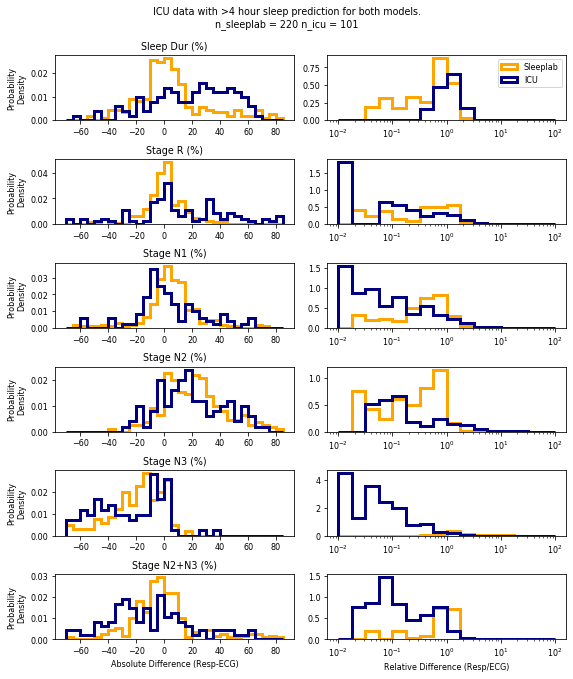

In [11]:
n_vars = len(var_names)
fig, ax = plt.subplots(n_vars, 2, figsize=(8,9))

icu_data = icu_4_strict.copy()
savename = 'icu_4_strict'

if savename == 'icu_4_strict':
    suptitle = f'ICU data with >4 hour sleep prediction for both models.\nn_sleeplab = {summary_days_sleeplab.shape[0]} n_icu = {icu_data.shape[0]}'
elif savename == 'icu_4':
    suptitle = f'ICU data with >4 hour sleep prediction for any of the two models.\nn_sleeplab = {summary_days_sleeplab.shape[0]} n_icu = {icu_data.shape[0]}'
elif savename == 'summary_dn_icu':
    suptitle = f'ICU data with all 12-hour segments.\nn_sleeplab = {summary_days_sleeplab.shape[0]} n_icu = {icu_data.shape[0]}'


for i_var in range(n_vars):
    
    var_tmp = variables_template[i_var]
    var_name_tmp = var_names[i_var]
    var_ecg = var_tmp.replace('MODALITY', 'ecg_nn')
    var_resp = var_tmp.replace('MODALITY', 'breathing')
    
    var_ecg_sleeplab = summary_days_sleeplab[var_ecg].values
    var_resp_sleeplab = summary_days_sleeplab[var_resp].values
    var_ecg_icu = icu_data[var_ecg].values
    var_resp_icu = icu_data[var_resp].values
    
    var_diff_abs_sleeplab = var_resp_sleeplab - var_ecg_sleeplab
    var_abs_diff_sleeplab_large = np.abs(var_diff_abs_sleeplab) > -1 # check relative difference only for those who have some absolute difference.
    var_diff_rel_sleeplab =  (var_ecg_sleeplab[var_abs_diff_sleeplab_large] + 1e-3)/ (var_resp_sleeplab[var_abs_diff_sleeplab_large] + 1e-3)
    var_diff_abs_icu = var_resp_icu - var_ecg_icu
    var_abs_diff_icu_large = np.abs(var_diff_abs_icu) > -1
    var_diff_rel_icu =  (var_resp_icu[var_abs_diff_icu_large] + 1e-3)/ (var_ecg_icu[var_abs_diff_icu_large] + 1e-3)

    summary_days_sleeplab[var_tmp.replace('MODALITY', 'diff_abs')] = var_diff_abs_sleeplab
    summary_days_sleeplab[var_tmp.replace('MODALITY', 'diff_rel')] = var_diff_rel_sleeplab
    icu_data[var_tmp.replace('MODALITY', 'diff_abs')] = var_diff_abs_icu
    icu_data[var_tmp.replace('MODALITY', 'diff_rel')] = var_diff_rel_icu

    ax[i_var, 0] = hist_diff_abs(ax[i_var, 0])
    ax[i_var, 1] = hist_diff_rel(ax[i_var, 1])
    ax[i_var, 0].set_title(var_name_tmp)

ax[0, 1].legend(['Sleeplab', 'ICU'])

for ax_tmp in ax.flatten()[:-2]:
    ax_tmp.set_xlabel('')
for ax_tmp in ax.flatten()[1::2]:
    ax_tmp.set_ylabel('')    
    
plt.suptitle(suptitle, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(plots_savedir, f'Model_Differences_AbsRel_Differences_{savename}.jpg'), dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(plots_savedir, f'Model_Differences_AbsRel_Differences_{savename}.svg'), bbox_inches='tight')
plt.show()


In [12]:
cols = ['study_id', 'day_cat', 'day_no', 'timerange', 'stages_distribution_diff_abs_R', 'stages_distribution_diff_abs_N3', 'stages_distribution_diff_abs_N2N3', 'sleep_hours_breathing', 'sleep_hours_ecg_nn']

In [13]:
# icu_data.loc[:, cols].sort_values(by='stages_distribution_diff_abs_R').to_csv(savename + '_model_diffs.csv')

In [17]:
icu_data.loc[:, cols].sort_values(by='stages_distribution_diff_abs_N2N3');

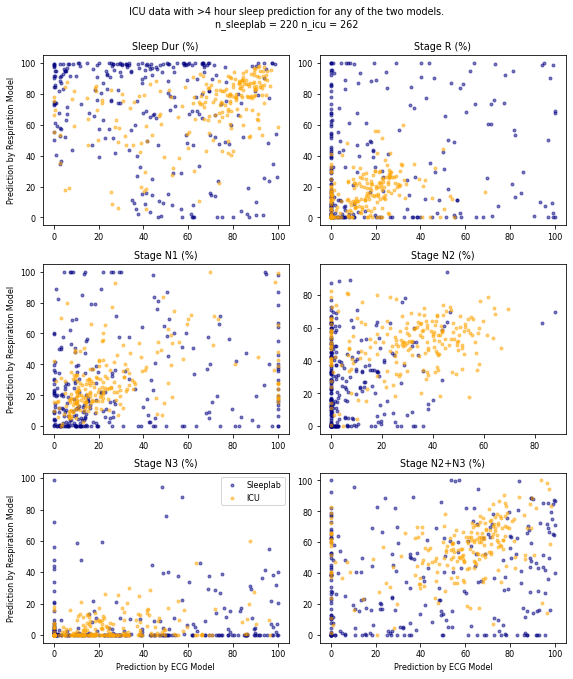

In [25]:
n_vars = len(var_names)
fig, ax = plt.subplots(int(np.ceil(n_vars/2)), 2, figsize=(8,9))
ax = ax.flatten()
s = 9
alpha = 0.5

for i_var in range(n_vars):
    
    var_tmp = variables_template[i_var]
    var_name_tmp = var_names[i_var]
    var_ecg = var_tmp.replace('MODALITY', 'ecg_nn')
    var_resp = var_tmp.replace('MODALITY', 'breathing')
    
    var_ecg_sleeplab = summary_days_sleeplab[var_ecg].values
    var_resp_sleeplab = summary_days_sleeplab[var_resp].values
    var_ecg_icu = icu_data[var_ecg].values
    var_resp_icu = icu_data[var_resp].values
    
    ax[i_var].scatter(var_ecg_icu, var_resp_icu, c=c_icu, s=s, alpha=alpha)
    ax[i_var].scatter(var_ecg_sleeplab, var_resp_sleeplab, c=c_sleeplab, s=s, alpha=alpha)

    ax[i_var].set_title(var_name_tmp)
    if i_var % 2 == 0:
        ax[i_var].set_ylabel('Prediction by Respiration Model')

ax[4].legend(['Sleeplab', 'ICU'])
ax[-1].set_xlabel('Prediction by ECG Model')
ax[-2].set_xlabel('Prediction by ECG Model')
plt.suptitle(suptitle, y=1.04)
plt.tight_layout()
plt.savefig(os.path.join(plots_savedir, f'Model_Differences_Scatter_{savename}.jpg'), dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(plots_savedir, f'Model_Differences_Scatter_{savename}.svg'), bbox_inches='tight')
plt.show()


In [84]:
i_var

4

In [108]:
10**0.3

1.9952623149688795

In [109]:
10**-0.3

0.5011872336272722

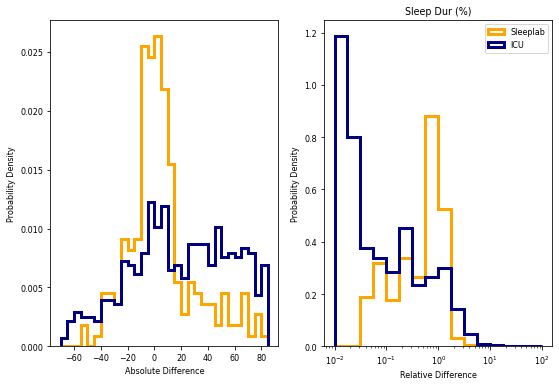

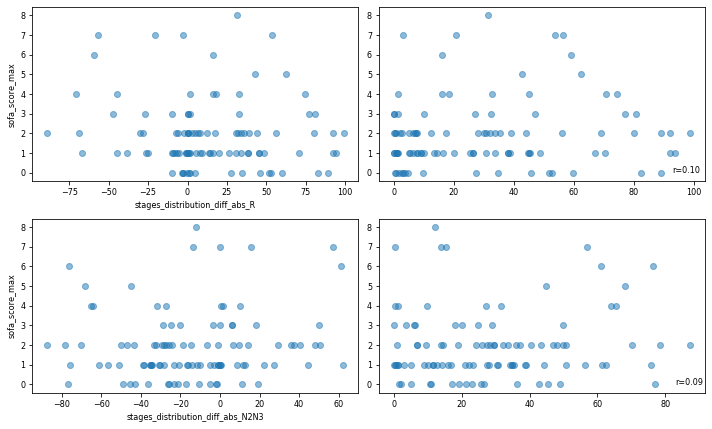

In [53]:
x = 'stages_distribution_diff_abs_R'
y = 'sofa_score_max'
savename = 'sofa'

fig, ax = plt.subplots(2, 2, figsize=(10,6))
ax = ax.flatten()
# ax[0].set_title()
ax[0].set_ylabel(y)
ax[0].scatter(icu_data[x], icu_data[y], alpha=0.5)
ax[1].scatter(icu_data[x].abs(), icu_data[y], alpha=0.5)
ax[1].text(93,0, f'r={np.corrcoef(icu_data[x].abs(), icu_data[y])[0,1]:.2f}')
ax[0].set_xlabel(x)

x = 'stages_distribution_diff_abs_N2N3'
ax[2].scatter(icu_data[x], icu_data[y], alpha=0.5)
ax[3].scatter(icu_data[x].abs(), icu_data[y], alpha=0.5)
ax[3].text(83,0, f'r={np.corrcoef(icu_data[x].abs(), icu_data[y])[0,1]:.2f}')

ax[2].set_ylabel(y)
ax[2].set_xlabel(x)

plt.tight_layout()
plt.savefig(os.path.join(plots_savedir, f'Model_Differences_Scatter_{savename}.jpg'), dpi=500, bbox_inches='tight')
plt.savefig(os.path.join(plots_savedir, f'Model_Differences_Scatter_{savename}.svg'), bbox_inches='tight')

In [ ]:
x = 'stages_distribution_diff_abs_R'
y = 'sofa_score_max'

fig, ax = plt.subplots(2, 2, figsize=(10,6))
ax = ax.flatten()
# ax[0].set_title()
ax[0].set_ylabel(y)
ax[0].scatter(icu_data[x], icu_data[y], alpha=0.5)
ax[1].scatter(icu_data[x].abs(), icu_data[y], alpha=0.5)
ax[1].text(93,0, f'r={np.corrcoef(icu_data[x].abs(), icu_data[y])[0,1]:.2f}')
ax[0].set_xlabel(x)

x = 'stages_distribution_diff_abs_N2N3'
ax[2].scatter(icu_data[x], icu_data[y], alpha=0.5)
ax[3].scatter(icu_data[x].abs(), icu_data[y], alpha=0.5)
ax[3].text(83,0, f'r={np.corrcoef(icu_data[x].abs(), icu_data[y])[0,1]:.2f}')

ax[2].set_ylabel(y)
ax[2].set_xlabel(x)

plt.tight_layout()

In [6]:
# ### 3x2 plot
# # cols: data type, rows: stage version (resp, ecg, expert)

# variables_template = ['sleep_hours_MODALITY',
#              'stages_distribution_MODALITY_S',
#              'stages_distribution_MODALITY_R',
#              'stages_distribution_MODALITY_N1',
#             'stages_distribution_MODALITY_N2',
#              'stages_distribution_MODALITY_N3',
#              'sleep_MODALITY_sfi',
#              'sleep_MODALITY_sfi_w',
#              'sleep_MODALITY_arousali',
#             ]
# x_labels = ['Sleep Dur. (h)', 'Sleep Efficiency', 'Stage R (%)', 'Stage N1 (%)', 'Stage N2 (%)', 'Stage N3 (%)', 'SFI', 'SFI Wake', 'Arousal I.']